# Clinical-Trial Drug-Demand — a compound model, cross-validated by complementary methods

## The problem

A clinical trial has to keep drug at its depots before it knows how much will be needed. Demand is
uncertain on two fronts at once: how many patients will actually enrol at a site over the coming
months, and how much drug each of them will consume before they finish or drop out. Ship too little
and a patient misses a dose; ship too much and expensive product expires unused. Sizing that buffer
— the *overage* — comes down to a single question: what does the far tail of total demand look like,
the 95th or 99th percentile rather than the average?

Total demand is a **compound distribution**: a random number of patients (enrolment), each consuming
a random amount (dose schedule, tempered by dropout). The whole planning decision rests on getting
that distribution — and especially its tail — right.

## The design: validate by complementary methods

The natural tool for a compound distribution is Monte Carlo — simulate many trials, read off the
distribution. But a simulator is only as trustworthy as its tail is stable, and the tail is exactly
the noisy part: the region that sizes the overage is where simulation is least reliable and hardest
to check. Extensive tests confirm the *code runs*; they do not confirm the *numbers are right*.

So the notebook is built around a cross-check — the same distribution computed by **independent,
complementary methods** that must agree:

- an **exact FFT convolution** of the compound distribution — the reference;
- a **Monte-Carlo simulation** — the independent stochastic check;
- the field-standard **`aggregate`** library — a second exact method, from a different codebase;
- plus **closed-form moments** and a **known-answer** case where the exact result is known outright.

<div style="background:#eef1f8;border-left:5px solid #6b7db3;border-radius:8px;padding:11px 16px;margin:14px 0;"><b style="color:#3f6bb0;font-size:11.5px;letter-spacing:.6px;">THE DESIGN</b><br>The complementarity is deliberate: an exact method and a stochastic one guard each other. The exact FFT anchors the tail the simulation is noisiest in; the simulation guards against a hidden error in the exact one; an independent library confirms both. Three methods agreeing on the 99th-percentile demand is the result the whole notebook is built to earn &mdash; and where they first <i>disagree</i> (&sect;3b) is where the real finding turns up.</div>

## How it is organised

Two separable halves:

1. **Acquisition** (§1–§2) grounds the model in reality, pulling enrolment, dropout, and dosing
   parameters from public registries (ClinicalTrials.gov v2, DailyMed v2). Needs network.
2. **Model & validation** (§3–§4) is the compound model, the complementary-methods cross-check, and
   the boundary of validity. Runs offline — from a frozen `params.json` if acquisition has run, or
   realistic built-in defaults.

Guiding principle: **real public parameters, synthetic generating layer** — real numbers from real
trials, each traceable by its NCT id, the simulation run from them, so the ground truth is known and
the study reproduces without re-fetching.

*Run top-to-bottom with Shift+Enter; cells build on the ones before them.*

## 0. Setup

In [1]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 01 · §0 · Environment setup                                    v1.0.1
# provides ▸ SESSION · RNG · CT_BASE · DM_BASE
# requires ▸ —
# ══════════════════════════════════════════════════════════════════════════

# PURPOSE : one-time setup shared by every later cell.
#   CT_BASE / DM_BASE : REST roots for the two public registries this notebook reads
#                       (ClinicalTrials.gov for trial protocols & results; DailyMed for
#                       FDA drug labels).
#   SESSION           : a single reused HTTP connection - carries the User-Agent on
#                       every request and avoids reopening a socket per call.
#   RNG               : a SEEDED generator, so every Monte-Carlo figure below is
#                       reproducible to the bit; change the seed to draw a fresh sample.
#   requests          : used only in the acquisition half (S1-S2); the model half
#                       (S3-S4) runs on numpy / pandas / matplotlib alone.

import time, math, json, pathlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

# heavy-tailed figures trigger matplotlib's loc="best" legend speed warning (harmless);
# also silence its re-render echo from the inline backend
warnings.filterwarnings("ignore", message='Creating legend with loc="best"')

CT_BASE = "https://clinicaltrials.gov/api/v2"
DM_BASE = "https://dailymed.nlm.nih.gov/dailymed/services/v2"
SESSION = requests.Session()
SESSION.headers.update({"User-Agent": "phnx-supply-validation/0.1 (research)"})
RNG = np.random.default_rng(20260728)

## 1. Choosing a cohort

The choice here is a data-quality question, not a clinical one — it needs no knowledge of the
drugs themselves. What matters is whether a therapeutic area carries enough of the right kind of
data for the statistics to behave. The table below summarises each candidate area on three axes:

- **`n_with_results`** — completed trials that actually posted results. This is the binding
  constraint: real dropout comes from the participant-flow section, which exists only once results
  are posted, so this count is what lets the attrition estimate rest on real records rather than an
  assumption.
- **`n_completed`** — the overall volume of completed phase-3 trials in the area, a sense of how
  much there is to draw on.
- **`median_enrollment`** — the typical trial size, which sets the scale of the demand
  distribution: large enough for the tail to be interesting, not so large that it becomes unwieldy.

Areas with simple, regular dosing ("X every N weeks") are the easiest to work with, since a steady
schedule turns cleanly into kits-per-patient, whereas a complex titration makes the consumption
model harder to keep honest. The candidate list is a starting menu; any therapeutic area can take
its place.

In [2]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 02 · §1 · Registry helpers (search + fetch)                              v1.0.0
# provides ▸ parse_ctgov_date · search_trials · fetch_full · participant_flow
# requires ▸ SESSION · CT_BASE
# ══════════════════════════════════════════════════════════════════════════

# PURPOSE : the two low-level helpers every acquisition cell leans on.
#
# parse_ctgov_date - the registry is inconsistent about date format: the same field
#   may arrive as an ISO day, a full US date, or month-only. We try each known shape
#   and return None on no match, so a malformed/missing date degrades instead of raising.
#
# search_trials - the v2 API paginates by CURSOR, not offset: each page carries a
#   'nextPageToken' you pass back as 'pageToken' to fetch the next. We loop until the
#   token disappears (last page) or we have enough rows. 'countTotal' asks the server to
#   include the total match count; raise_for_status turns an HTTP error into a Python
#   exception; the 0.3s pause is politeness to a public endpoint.

def parse_ctgov_date(s):
    # API emits three shapes: 2024-01-15 | January 2024 | January 15, 2024
    if not s:
        return None
    from datetime import datetime
    for fmt in ("%Y-%m-%d", "%B %d, %Y", "%B %Y", "%Y-%m"):
        try:
            return datetime.strptime(s, fmt)
        except ValueError:
            continue
    return None

def search_trials(params, max_results=None):
    # Cursor-paginated search over /studies. Returns list of study dicts.
    out = []
    page = {**params, "pageSize": 1000, "countTotal": "true"}
    while True:
        r = SESSION.get(f"{CT_BASE}/studies", params=page, timeout=30)
        r.raise_for_status()
        data = r.json()
        out.extend(data.get("studies", []))
        tok = data.get("nextPageToken")
        if not tok or (max_results and len(out) >= max_results):
            break
        page = {**params, "pageSize": 1000, "pageToken": tok}
        time.sleep(0.3)
    return out[:max_results] if max_results else out


# --- results fetch (defined here, early, so any dropout cell can use them) ---
from functools import lru_cache

@lru_cache(maxsize=None)
def fetch_full(nct):
    """Fetch one complete study record by NCT id (None on 404). Cached to save bandwidth."""
    r = SESSION.get(f"{CT_BASE}/studies/{nct}", timeout=30)
    if r.status_code == 404:
        return None
    r.raise_for_status()
    return r.json()

def participant_flow(nct):
    """The participantFlowModule for a trial, or {} if it posted no results."""
    return (fetch_full(nct) or {}).get("resultsSection", {}).get("participantFlowModule", {})


In [3]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 03 · §1 · Cohort menu                                          v1.0.0
# provides ▸ CANDIDATES · is_phase3 · is_interventional · completed_query
#            cohort_summary · menu
# requires ▸ search_trials
# ══════════════════════════════════════════════════════════════════════════

# PURPOSE : build the data-quality table you choose a cohort from.
#
# Each candidate is (label, condition, intervention); "" for intervention searches the
# whole indication. The choice is a DATA question, not a clinical one - you read three
# columns: n_with_results (binding: real dropout needs posted results), n_completed
# (volume), median_enrollment (scale of the demand distribution).
#
# FILTERING : v2 accepts query.cond / query.intr / filter.overallStatus, but has NO
# filter.phase or filter.studyType. So completed_query asks the server only for completed
# trials matching the condition, and we keep phase-3 interventional ones ourselves by
# reading designModule (is_phase3 / is_interventional). Counts are 'within the first cap'
# - a decision aid, not a census.

# (label, query.cond, query.intr)  -- intr optional; "" searches the whole area
CANDIDATES = [
    ("Statins / cholesterol",   "hypercholesterolemia", "statin"),
    ("Type 2 diabetes / GLP-1", "type 2 diabetes",      "glp-1"),
    ("RA / biologics",          "rheumatoid arthritis", ""),
    ("Asthma / inhaled",        "asthma",               ""),
    ("Hypertension",            "hypertension",         ""),
]

# phase & study-type are NOT v2 filter params -> filter client-side from designModule
def _design(s):        return s.get("protocolSection", {}).get("designModule", {})
def is_phase3(s):      return "PHASE3" in (_design(s).get("phases") or [])
def is_interventional(s): return _design(s).get("studyType") == "INTERVENTIONAL"

def completed_query(cond, intr):
    q = {"query.cond": cond, "filter.overallStatus": "COMPLETED"}   # valid params only
    if intr:
        q["query.intr"] = intr
    return q

def cohort_summary(cond, intr, cap=400):
    studies = search_trials(completed_query(cond, intr), max_results=cap)
    studies = [s for s in studies if is_phase3(s) and is_interventional(s)]
    with_results = [s for s in studies if s.get("hasResults")]
    enr = [((s.get("protocolSection", {}).get("designModule", {})
              .get("enrollmentInfo", {}) or {}).get("count")) for s in with_results]
    enr = [e for e in enr if e]
    return {"n_completed": len(studies),          # phase-3 interventional, within cap
            "n_with_results": len(with_results),
            "median_enrollment": int(np.median(enr)) if enr else None}

rows = []
for label, cond, intr in CANDIDATES:
    r = cohort_summary(cond, intr); r["cohort"] = label
    rows.append(r); time.sleep(0.3)
menu = pd.DataFrame(rows)[["cohort", "n_completed", "n_with_results", "median_enrollment"]]
menu

,cohort,n_completed,n_with_results,median_enrollment
0,Statins / cholesterol,62,38,408
1,Type 2 diabetes / GLP-1,95,74,479
2,RA / biologics,68,47,511
3,Asthma / inhaled,55,24,328
4,Hypertension,54,18,389


With the table in view, the choice becomes a reading exercise. `n_with_results` is the column that
carries the most weight, since it sets how much real dropout data the attrition estimate can draw
on, while `median_enrollment` fixes the scale of the demand distribution the model will produce. A
row that is healthy on the first and workable on the second is the one that makes the rest of the
notebook behave. That choice is recorded in the next cell, which fixes the cohort every later cell
reads from.

In [4]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 04 · §1 · Cohort selection                                     v1.0.0
# provides ▸ CHOICE · cond · intr
# requires ▸ CANDIDATES
# ══════════════════════════════════════════════════════════════════════════

# PURPOSE : record the cohort chosen from the table above. This fixes (cond, intr),
# the two query terms every S2 acquisition cell reads from, so the decision is made once,
# here, and the comment carries the reasoning behind it.

# Cohort selected by reading the data-quality table above.
# Type 2 diabetes / GLP-1 carried the most results-posted trials (real dropout data),
# with a workable median enrolment — see the earlier table for the comparison.
CHOICE = "Type 2 diabetes / GLP-1"
cond, intr = next((c, i) for (l, c, i) in CANDIDATES if l == CHOICE)
print("Cohort:", CHOICE, "| cond=", cond, "| intr=", intr or "(none)")

Cohort: Type 2 diabetes / GLP-1 | cond= type 2 diabetes | intr= glp-1


## 2. Acquiring real parameters  *(network)*

This is the half that grounds the model in reality: it turns records from public registries into the
three inputs the compound model needs — an enrolment law, a dropout hazard, and a per-patient
consumption distribution. It is also the only half that touches the network. Because the model half
carries realistic defaults, these cells are optional: running them replaces those defaults with
numbers traceable to real trials, but the validation works without them.

### 2a. Enrolment → a Negative Binomial law for N

The number of patients a depot sees is a count, and trial-to-trial it varies more than a plain
Poisson would allow — sites recruit at different rates, so the underlying Poisson rate is itself
random. Mixing a Poisson rate over a Gamma spread gives the Negative Binomial, which captures that
over-dispersion while keeping a closed-form probability generating function. That last property is
what matters downstream: it is exactly the pgf the FFT convolution applies, so the enrolment law
drops straight into the exact reference without approximation.

In [5]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 05 · §2a · Enrolment extraction                                v1.0.0
# provides ▸ enrolment_row · studies · enr_df
# requires ▸ search_trials · completed_query · is_phase3 · is_interventional
#            parse_ctgov_date · cond · intr
# ══════════════════════════════════════════════════════════════════════════

# PURPOSE : turn each trial record into one row of transferable enrolment numbers.
#
# A `study` is a full ClinicalTrials.gov JSON record, nested under protocolSection and
# split into 'modules'. enrolment_row navigates that nesting (chained .get(...,{}) guard
# against any module being absent) and reads a few fields verbatim:
#     nctId                        <- identificationModule     (registry id)
#     enrollmentInfo.count / .type <- designModule             (count; ACTUAL vs ESTIMATED)
#     start / completion dates     <- statusModule             (trial span)
#     len(locations)               <- contactsLocationsModule  (number of sites)
#
# It then DERIVES the one number that transfers across trials:
#     rate_per_site_month = count / n_sites / months
# A raw count of 400 is meaningless without knowing over how many sites and how long;
# dividing it out yields a per-site monthly recruitment rate that CODE #6 projects onto
# your own depot. This treats enrolment as ~linear in time and uniform across sites - a
# deliberate first-order simplification; the NB over-dispersion in CODE #6 absorbs much
# of the site-to-site variation it ignores.
#
# The two filters at the end keep only rows with a real (ACTUAL) count - dropping planned
# ESTIMATED targets - and a well-formed rate.

def enrolment_row(study):
    ps    = study.get("protocolSection", {})
    ident = ps.get("identificationModule", {})
    stat  = ps.get("statusModule", {})
    des   = ps.get("designModule", {})
    locs  = ps.get("contactsLocationsModule", {}).get("locations", []) or []
    enr   = (des.get("enrollmentInfo") or {})
    start = parse_ctgov_date((stat.get("startDateStruct") or {}).get("date"))
    end   = parse_ctgov_date((stat.get("completionDateStruct") or {}).get("date"))
    months = max((end.year-start.year)*12 + (end.month-start.month), 1) if (start and end) else None
    count  = enr.get("count")
    n_sites = len(locs)
    return {"nct": ident.get("nctId"), "enrollment": count,
            "enrollment_type": enr.get("type"), "months": months, "n_sites": n_sites,
            "rate_per_site_month": (count/n_sites/months)
                if (count and n_sites and months) else None}

studies = search_trials(completed_query(cond, intr), max_results=300)
studies = [s for s in studies if is_phase3(s) and is_interventional(s)]
enr_df = pd.DataFrame([enrolment_row(s) for s in studies])
enr_df = enr_df[enr_df["enrollment_type"] == "ACTUAL"].dropna(subset=["rate_per_site_month"])
print(f"usable trials: {len(enr_df)}")
enr_df.head()

usable trials: 66


,nct,enrollment,enrollment_type,months,n_sites,rate_per_site_month
0,NCT01270789,63,ACTUAL,40,1,1.575000
1,NCT01541215,135,ACTUAL,90,185,0.008108
2,NCT00331851,584,ACTUAL,11,116,0.457680
3,NCT06739044,494,ACTUAL,17,1,29.058824
4,NCT00333151,576,ACTUAL,15,89,0.431461


### 2a′. Curating the cohort by trial design

The keyword search that built this cohort matches drug *names*, not trial *shape*, so it can pull
in studies whose design doesn't fit what the model assumes — a patient on one regimen, taken
repeatedly over months. The next two cells flag the likely mismatches (chiefly **crossover** trials,
where each patient receives several drugs in sequence, and **single-dose** studies, where there is
no ongoing consumption), leaving a shortlist to eyeball rather than the whole list. The flagging is
a starting point, not a verdict — you keep or drop each trial yourself in the second cell. That
curation, matching the trials to the assumption, is domain judgement a generic scraper wouldn't
apply, and it's worth a sentence in the writeup.

In [6]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 05A · §2a · Curate: flag design mismatches                     v1.0.0
# provides ▸ design_flags · review
# requires ▸ studies · parse_ctgov_date
# ══════════════════════════════════════════════════════════════════════════

# PURPOSE : flag trials whose DESIGN probably doesn't match the model's assumptions,
# so your manual pass starts from a shortlist instead of every record.
#
# The model assumes a "chronic, parallel-group" trial: each patient is on ONE regimen
# and takes it repeatedly over months (that is what X = dose x (administrations before
# dropout) describes). The keyword search matches drug NAMES, not trial SHAPE, so it can
# pull in studies that look nothing like that and would distort the consumption model:
#   - CROSSOVER : each patient gets several drugs in sequence with a "washout" gap
#                 between them -> not "one regimen over months".
#   - single-dose / PK : one administration to measure drug behaviour -> no ongoing use.
#   - non-TREATMENT purpose (prevention, diagnostic, basic science) -> a different animal.
#   - very short duration -> a chronic-treatment phase-3 usually runs many months.
# design_flags returns a plain-English reason for each mismatch; NO flags => it looks
# like the chronic parallel-group trial you want.

def design_flags(study):
    ps = study.get("protocolSection", {})
    di = ps.get("designModule", {}).get("designInfo", {}) or {}
    model   = di.get("interventionModel")      # PARALLEL / CROSSOVER / SINGLE_GROUP / ...
    purpose = di.get("primaryPurpose")         # TREATMENT / PREVENTION / DIAGNOSTIC / ...
    ai = ps.get("armsInterventionsModule", {})
    text = " ".join(
        [di.get("interventionModelDescription") or ""]
        + [(a.get("description") or "") for a in (ai.get("armGroups") or [])]
        + [(i.get("description") or "") for i in (ai.get("interventions") or [])]
    ).lower()
    stat = ps.get("statusModule", {})
    start = parse_ctgov_date((stat.get("startDateStruct") or {}).get("date"))
    end   = parse_ctgov_date((stat.get("completionDateStruct") or {}).get("date"))
    months = ((end.year-start.year)*12 + (end.month-start.month)) if (start and end) else None

    reasons = []
    if model == "CROSSOVER":
        reasons.append("crossover (multiple drugs per patient w/ washout)")
    if purpose and purpose != "TREATMENT":
        reasons.append(f"purpose={purpose.lower()} (not chronic treatment)")
    for kw in ("single dose", "single-dose", "single ascending", "pharmacokinetic", "washout"):
        if kw in text:
            reasons.append(f"text mentions '{kw}'"); break
    if months is not None and months < 3:
        reasons.append(f"very short ({months} mo)")
    return reasons

# Inspect-first: confirm the design fields are actually being read (same habit as dropout).
_d = (studies[0].get("protocolSection", {}).get("designModule", {}).get("designInfo", {}) or {}) if studies else {}
print("sample designInfo:", {k: _d.get(k) for k in ("interventionModel", "primaryPurpose", "allocation")})

# Review table over every fetched trial, most-suspicious first.
review = []
for s in studies:
    nct = s.get("protocolSection", {}).get("identificationModule", {}).get("nctId")
    fl = design_flags(s)
    review.append({"nct": nct, "flags": "; ".join(fl), "looks_chronic": len(fl) == 0})
review = pd.DataFrame(review)
print(f"{int(review['looks_chronic'].sum())} of {len(review)} look like chronic parallel-group trials")
review.sort_values("looks_chronic").head(40)      # flagged ones shown first


sample designInfo: {'interventionModel': 'PARALLEL', 'primaryPurpose': 'TREATMENT', 'allocation': 'RANDOMIZED'}
58 of 70 look like chronic parallel-group trials


,nct,flags,looks_chronic
18,NCT00230464,crossover (multiple drugs per patient w/ washout),False
30,NCT03439072,crossover (multiple drugs per patient w/ washout),False
47,NCT01959334,purpose=other (not chronic treatment),False
52,NCT01937598,crossover (multiple drugs per patient w/ washo...,False
55,NCT02889510,crossover (multiple drugs per patient w/ washout),False
14,NCT05691712,text mentions 'single-dose',False
13,NCT00747968,crossover (multiple drugs per patient w/ washo...,False
12,NCT04466618,purpose=basic_science (not chronic treatment),False
58,NCT03895697,crossover (multiple drugs per patient w/ washout),False
37,NCT00390520,crossover (multiple drugs per patient w/ washout),False


In [7]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 05B · §2a · Curate: apply your keep-list                       v1.0.0
# provides ▸ enr_kept
# requires ▸ review · enr_df
# ══════════════════════════════════════════════════════════════════════════

# PURPOSE : keep only the trials you trust, into a NEW frame enr_kept - never overwriting
# enr_df. CODE #6/#7/#8 read enr_kept, so re-running CODE #5 (which rebuilds enr_df) can
# no longer clobber the curation. To hand-curate, read the `review` table and edit KEEP;
# it is just a list of NCT ids.

KEEP = review.loc[review["looks_chronic"], "nct"].tolist()   # <-- edit by hand if needed
# add one back:  KEEP.append("NCT01234567")
# drop one:      KEEP = [n for n in KEEP if n != "NCT07654321"]

enr_kept = enr_df[enr_df["nct"].isin(KEEP)].reset_index(drop=True)
print(f"kept {len(enr_kept)} of {len(enr_df)} usable trials after design curation")
enr_kept.head()


kept 56 of 66 usable trials after design curation


,nct,enrollment,enrollment_type,months,n_sites,rate_per_site_month
0,NCT01270789,63,ACTUAL,40,1,1.575000
1,NCT01541215,135,ACTUAL,90,185,0.008108
2,NCT00331851,584,ACTUAL,11,116,0.457680
3,NCT06739044,494,ACTUAL,17,1,29.058824
4,NCT00333151,576,ACTUAL,15,89,0.431461


In [8]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 06 · §2a · Negative-Binomial fit for N                         v1.0.0
# provides ▸ K_SITES · HORIZON_M · enrolment_law
# requires ▸ enr_kept
# ══════════════════════════════════════════════════════════════════════════

# PURPOSE : project the per-trial site-rates onto YOUR depot, then fit the count law N.
#
# depot_counts = rate_per_site_month * K_SITES * HORIZON_M is, for each curated trial,
# the enrolment your depot would see at that trial's pace over your horizon. Across trials
# these vary more than a Poisson allows, so we fit a Negative Binomial by moments:
#     mean m, var v (v>m)  ->  p = m/v,   r = m^2/(v-m)
# The NB keeps a closed-form pgf - exactly what the FFT reference in S3 consumes. If the
# sample is under-dispersed (v<=m, rare) we fall back to Poisson(m). K_SITES and HORIZON_M
# are your scenario knobs - change them to size a different depot.

if "enr_kept" not in dir():
    raise NameError("run 05A then 05B first: enr_kept (curated cohort) is not defined")

# depot scenario knobs -- HORIZON_M is a planning CHOICE (how far ahead the depot
# plans enrolment), not a fact. 12 = one year of forward cover for this GLP-1 cohort.
K_SITES, HORIZON_M = 5, 12

rates = enr_kept["rate_per_site_month"].to_numpy()
depot_counts = rates * K_SITES * HORIZON_M          # implied enrolment per depot per horizon
m, v = depot_counts.mean(), depot_counts.var(ddof=1)
if v > m:
    p_nb, r_nb = m/v, m*m/(v-m)
    enrolment_law = {"dist": "negbin", "r": float(r_nb), "p": float(p_nb),
                     "mean": float(m), "var": float(v), "n_trials": int(len(rates))}
else:                                                # under-dispersed fallback
    enrolment_law = {"dist": "poisson", "lam": float(m),
                     "mean": float(m), "var": float(m), "n_trials": int(len(rates))}
enrolment_law


{'dist': 'negbin',
 'r': 0.14744545175703386,
 'p': 0.001198248252808447,
 'mean': 122.90339264581758,
 'var': 102569.22332893651,
 'n_trials': 56}

### 2b. Dropout  ->  attrition hazard
Dropout lives in the **results** section (present only when results were posted) and its leaf names
vary a little across records. **Inspect one real record first**, then code against what you see.

In [9]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 07 · §2b · Results fetch + inspect                             v1.0.0
# provides ▸ fetch_full
# requires ▸ SESSION · CT_BASE · enr_df
# ══════════════════════════════════════════════════════════════════════════

# PURPOSE : inspect the real shape of the dropout data before extracting it.
#
# Dropout lives in the RESULTS section, present only when a trial POSTED results. We read
# the curated keep-set only (enr_kept), so a flagged trial can't leak into the dropout
# step. Some curated trials may still have no results; we find the first that DOES to
# eyeball, and report how many carry results - that subset is what CODE #8 averages over.

if "enr_kept" not in dir():
    raise NameError("run 05A then 05B first: enr_kept (curated cohort) is not defined")

with_flow = [n for n in enr_kept["nct"] if participant_flow(n)]
print(f"{len(with_flow)} of {len(enr_kept)} curated trials posted participant-flow results")
if with_flow:
    print(json.dumps(participant_flow(with_flow[0]), indent=2)[:1500])
else:
    print("No curated trial posted results - the hazard will fall back (see CODE #8).")


44 of 56 curated trials posted participant-flow results
{
  "preAssignmentDetails": "Eligible subjects entered an 11- to 12-week run-in period where they were to undergo a 3-4 week titration of metformin to a maximum tolerated dose of metformin (\u22651000 mg and \u22642000 mg per day) followed by an 8-week maintenance period.",
  "recruitmentDetails": "The trial was conducted at 84 sites in 25 countries.",
  "groups": [
    {
      "id": "FG000",
      "title": "Liraglutide 1.8 mg",
      "description": "After the run-in period, subjects were randomized to receive liraglutide subcutaneous injections once daily (in combination with metformin with or without basal insulin, on a background of diet and exercise) for 52 weeks (26 weeks double blind treatment period followed by a 26-week open-label extension period). The liraglutide dosing was started at 0.6 mg/day during the first week and escalated in weekly increments of 0.6 mg over the following 2-3 weeks. Dose escalation was based on t

In [10]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 08 · §2b · Attrition hazard                                    v1.0.0
# provides ▸ completion_fraction · comp_frac · T_TREAT_M · attrition_law
# requires ▸ fetch_full · enr_df
# ══════════════════════════════════════════════════════════════════════════

# PURPOSE : convert participant flow into a per-month dropout hazard.
#
# The flow's first period lists milestones; STARTED and COMPLETED, pooled across arms,
# give a completion fraction per trial. We turn the average completion into a constant
# hazard via  completion = exp(-lambda * T_treat)  =>  lambda = -ln(completion)/T_treat.
# Constant hazard is a deliberately simple first cut; richer per-period milestones would
# let you fit a stepwise or Weibull hazard instead. T_TREAT_M is the treatment window.

if "enr_kept" not in dir():
    raise NameError("run 05A then 05B first: enr_kept (curated cohort) is not defined")
def completion_fraction(nct):
    pf = (fetch_full(nct) or {}).get("resultsSection", {}).get("participantFlowModule", {})
    periods = pf.get("periods", [])
    if not periods:
        return None
    ms = periods[0].get("milestones", [])
    def total(mtype):
        for mm in ms:
            if mm.get("type", "").upper() == mtype:
                return sum(int(a.get("numSubjects", 0)) for a in mm.get("achievements", []))
        return None
    started, completed = total("STARTED"), total("COMPLETED")
    return completed/started if (started and completed is not None and started > 0) else None

fracs = [f for f in (completion_fraction(n) for n in enr_kept["nct"]) if f is not None]
comp_frac = float(np.mean(fracs)) if fracs else None

# T_TREAT_M = length of the treatment period the completion fraction is measured over.
# This cohort's primary period is ~72 weeks (16.6 months); we model that primary period
# and treat the branching week-176 extension as a v2 refinement.
T_TREAT_M = 16.6
haz = (-math.log(comp_frac)/T_TREAT_M) if comp_frac else None    # constant-hazard approx
attrition_law = {"completion_fraction": comp_frac, "hazard_per_month": haz,
                 "T_treat_months": T_TREAT_M, "n_trials": len(fracs)}
attrition_law

{'completion_fraction': 0.8758653943284899,
 'hazard_per_month': 0.007984509596080144,
 'T_treat_months': 16.6,
 'n_trials': 44}

### 2c. Dosing  ->  per-patient consumption inputs
Regimen from the trial's own arms (free text, trial-specific) or DailyMed's structured label.
We keep just what the severity model needs: kits per administration and the dosing interval.

In [11]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 09 · §2c · Dosing inputs                                       v1.0.0
# provides ▸ interventions · dailymed_setid · consumption_inputs
# requires ▸ SESSION · DM_BASE
# ══════════════════════════════════════════════════════════════════════════

# PURPOSE : derive the two numbers the consumption model needs - kits per
# administration and the dosing interval - from the regimen.
#
# Two sources: (a) the trial's own arms (armsInterventionsModule) - free text, trial-
# specific; (b) DailyMed's structured FDA label via dailymed_setid -> the SPL, when you
# want the approved regimen rather than the protocol's. For a simple oral regimen, 1 kit
# per administration is the natural default; set the interval from the protocol. These
# feed the severity (per-patient X) model in CODE #11.

def interventions(study):
    ai = study.get("protocolSection", {}).get("armsInterventionsModule", {})
    return {"arm_groups": ai.get("armGroups", []),
            "interventions": ai.get("interventions", [])}

def dailymed_setid(drug_name):
    r = SESSION.get(f"{DM_BASE}/spls.json", params={"drug_name": drug_name, "pagesize": 5}, timeout=30)
    r.raise_for_status()
    data = r.json().get("data", [])
    return data[0]["setid"] if data else None

# 1 kit per administration; interval from the regimen. This GLP-1 cohort doses WEEKLY,
# so the interval is 7/30.44 months, not monthly - the model builds a patient's kit
# count as (horizon / interval), so a monthly value would undercount ~4x.
DOSE_PER_ADMIN_KITS = 1.0
ADMIN_INTERVAL_M    = 7/30.44          # weekly dosing  (~0.23 months)
consumption_inputs  = {"dose_per_admin_kits": DOSE_PER_ADMIN_KITS,
                       "admin_interval_months": ADMIN_INTERVAL_M}
consumption_inputs

{'dose_per_admin_kits': 1.0, 'admin_interval_months': 0.22996057818659657}

In [12]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 10 · §2 · Freeze params.json                                   v1.0.0
# provides ▸ params · params.json
# requires ▸ CHOICE · enr_kept · K_SITES · HORIZON_M · enrolment_law
#            attrition_law · consumption_inputs
# ══════════════════════════════════════════════════════════════════════════

# PURPOSE : freeze the three fitted laws into params.json so the model half runs offline
# and reproducibly. provenance records the exact NCT ids behind the numbers - a reader can
# open each trial and check them, which is what makes 'real parameters' defensible rather
# than asserted.

params = {
    "provenance": {"source": "ClinicalTrials.gov v2 + DailyMed v2",
                   "cohort": CHOICE, "nct_ids": enr_kept["nct"].tolist()},
    "scenario": {"depot_sites": K_SITES, "horizon_months": HORIZON_M},
    "enrolment_law":   enrolment_law,
    "attrition_law":   attrition_law,
    "consumption_inputs": consumption_inputs,
}
pathlib.Path("params.json").write_text(json.dumps(params, indent=2))
print("wrote params.json for cohort:", CHOICE)

wrote params.json for cohort: Type 2 diabetes / GLP-1


## 3. The model — offline from here

From here the notebook runs without network: it loads `params.json` if acquisition built it,
otherwise realistic built-in defaults.

Total demand is the compound sum $S = \sum_{i=1}^{N} X_i$ — a random number of patients $N$, each
consuming a random number of kits $X$. Two ingredients, both estimated from real trials.

**The patient count $N$ is not Poisson.** If every trial recruited at the same fixed rate, the count
would be Poisson (variance = mean). Real enrolment is far more variable — some trials recruit
enormously faster than others — so it is *over-dispersed*, and modelled by a **Negative Binomial**.

<div style="background:#f2edfa;border-left:5px solid #b39ddb;border-radius:8px;padding:11px 16px;margin:14px 0;"><b style="color:#7a5fb0;font-size:11.5px;letter-spacing:.6px;">WHY THE GAMMA APPEARS</b><br>Let the Poisson rate itself be random: each trial draws a rate multiplier from a <b>Gamma</b> distribution, then enrols Poisson-style at that rate. Averaging over the Gamma-drawn rates gives exactly a <b>Negative Binomial</b> &mdash; a Poisson rate mixed by a Gamma <i>is</i> an NB. The Gamma&rsquo;s spread is the single knob for how heavy the enrolment tail becomes; here it is severe, which is what makes the demand tail &mdash; and the overage &mdash; so large.</div>

**Per-patient consumption $X$** is built from the dosing schedule and the dropout hazard: one kit per
weekly cycle, survival $e^{-\lambda\Delta}$ per cycle, capped at the horizon. Build and ship this
core first; the dependence extensions in §4 are a v2.

In [13]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 11 · §3 · Load params, build N and X                           v1.0.0
# provides ▸ P · N_KIND · N_ARGS · severity_pmf · SEV
# requires ▸ params.json | DEFAULT_PARAMS
# ══════════════════════════════════════════════════════════════════════════

# PURPOSE : the bridge from data to model. Load params (or fall back to realistic
# DEFAULT_PARAMS if you haven't run S2) and build the two ingredients of the compound sum
# S = X_1 + ... + X_N:
#   N (counting law) : Poisson or Negative Binomial, from enrolment_law.
#   X (severity)     : per-patient kits. severity_pmf models a patient getting one
#                      administration per cycle and dropping out with per-cycle probability
#                      (1 - q_cont), capped at the horizon - so A, the number of
#                      administrations, has a (truncated) geometric shape and X = dose * A.
#                      Fixing the horizon keeps X independent of N, which is what makes the
#                      FFT reference in S3 EXACT.

DEFAULT_PARAMS = {
    "scenario": {"depot_sites": 5, "horizon_months": 6},
    "enrolment_law": {"dist": "negbin", "mean": 60.0, "var": 110.0},
    "attrition_law": {"hazard_per_month": 0.08, "T_treat_months": 6.0},
    "consumption_inputs": {"dose_per_admin_kits": 1.0, "admin_interval_months": 1.0},
}
P = json.loads(pathlib.Path("params.json").read_text()) if pathlib.Path("params.json").exists() else DEFAULT_PARAMS
if "enrolment_law" not in P: P = DEFAULT_PARAMS
print("using", "params.json" if pathlib.Path('params.json').exists() else "DEFAULT_PARAMS")

# ---- N: counting law ----
el = P["enrolment_law"]
if el.get("dist") == "poisson":
    N_KIND, N_ARGS = "poisson", (el.get("lam", el["mean"]),)
else:
    m, v = el["mean"], el.get("var", el["mean"]*1.5)
    v = max(v, m*1.0001)                       # guard var>mean
    p, r = m/v, m*m/(v-m)
    N_KIND, N_ARGS = "negbin", (r, p)

# ---- X: per-patient kits, tied honestly to dropout ----
haz      = P["attrition_law"]["hazard_per_month"]
interval = P["consumption_inputs"]["admin_interval_months"]
dose     = P["consumption_inputs"]["dose_per_admin_kits"]
horizon  = P["scenario"]["horizon_months"]
q_cont   = math.exp(-haz*interval)             # per-cycle continuation prob
K_MAX    = max(int(round(horizon/interval)), 1)

def severity_pmf():
    # A = number of administrations before dropout or horizon cap (A=1..K_MAX)
    pmf_A = np.zeros(K_MAX+1)
    for a in range(1, K_MAX+1):
        pmf_A[a] = (q_cont**(a-1))*(1-q_cont) if a < K_MAX else q_cont**(K_MAX-1)
    # kits = dose * A  ->  place mass on integer kit lattice
    kits = (dose*np.arange(K_MAX+1)).round().astype(int)
    L = kits.max()+1
    f = np.zeros(L)
    for a in range(1, K_MAX+1):
        f[kits[a]] += pmf_A[a]
    return f/f.sum()

SEV = severity_pmf()
print("N:", N_KIND, N_ARGS, "| severity support (kits):", len(SEV)-1, "| E[X]=",
      round((np.arange(len(SEV))*SEV).sum(), 3))

using params.json
N: negbin (0.14744545175703386, 0.001198248252808447) | severity support (kits): 52 | E[X]= 49.64


### 3a. Compound distribution: FFT reference and Monte Carlo

`S = X_1 + ... + X_N`. FFT: apply the counting law's pgf to the DFT of the severity, invert.
For Poisson, `psi = exp(lam*(phi-1))`; for NB(r,p), `psi = (p/(1-(1-p)*phi))**r`.

In [14]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 12 · §3a · FFT reference (compound convolution)                v1.1.0
# provides ▸ count_pgf · aggregate_fft · fit_lattice · M · AGG · S_LATTICE
#            CDF · q_fft · Q50 · Q95 · Q99
# requires ▸ SEV · N_KIND · N_ARGS
# ══════════════════════════════════════════════════════════════════════════

# PURPOSE : build the exact FFT reference AND the quantities every test/figure reads.
#
# The aggregate pmf is the severity FFT with the count pgf applied, inverted. The lattice M
# must exceed the aggregate's support or the tail WRAPS AROUND (aliasing) - and this cohort's
# enrolment law is so heavy-tailed that a fixed safety-factor guess is unsafe. fit_lattice
# instead GROWS M until the top-of-lattice mass is negligible, so the tail is captured. We
# then compute AGG, its CDF, and the quantiles ONCE here; downstream cells never recompute.

def poisson_pgf(lam): return lambda z: np.exp(lam*(z-1.0))
def negbin_pgf(r, p):  return lambda z: (p/(1.0-(1.0-p)*z))**r
def count_pgf():
    return poisson_pgf(*N_ARGS) if N_KIND == "poisson" else negbin_pgf(*N_ARGS)

def aggregate_fft(sev_pmf, pgf, M):
    f = np.zeros(M); f[:len(sev_pmf)] = sev_pmf
    agg = np.clip(np.fft.ifft(pgf(np.fft.fft(f))).real, 0, None)
    return agg / agg.sum()

def fit_lattice(sev_pmf, pgf, start_pow=8, max_pow=23, tail_tol=1e-9):
    # grow M (power of 2) until the aggregate's top 2% of lattice holds < tail_tol mass,
    # i.e. nothing meaningful has wrapped. Returns (M, agg) - the smallest safe lattice.
    for k in range(start_pow, max_pow + 1):
        M = 1 << k
        agg = aggregate_fft(sev_pmf, pgf, M)
        if agg[int(0.98 * M):].sum() < tail_tol:
            return M, agg
    return M, agg

MEAN_N = N_ARGS[0] if N_KIND == "poisson" else N_ARGS[0]*(1-N_ARGS[1])/N_ARGS[1]
M, AGG = fit_lattice(SEV, count_pgf())          # sized to THIS distribution, once
S_LATTICE = np.arange(len(AGG))
CDF = np.cumsum(AGG)
def q_fft(a): return int(np.searchsorted(CDF, a))
Q50, Q95, Q99 = q_fft(0.50), q_fft(0.95), q_fft(0.99)
print(f"FFT lattice M = {M:,} | E[S] = {(S_LATTICE*AGG).sum():.0f} | "
      f"q50={Q50:,}  q95={Q95:,}  q99={Q99:,}")


FFT lattice M = 1,048,576 | E[S] = 6101 | q50=233  q95=33,707  q99=79,292


In [15]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 13 · §3a · Monte Carlo                                         v1.0.0
# provides ▸ sampler_N · sampler_X · aggregate_mc · S_MC
# requires ▸ SEV · N_KIND · N_ARGS · RNG
# ══════════════════════════════════════════════════════════════════════════

def sampler_N(rng, size):
    if N_KIND == "poisson":
        return rng.poisson(N_ARGS[0], size=size)
    r, p = N_ARGS
    return rng.negative_binomial(r, p, size=size)

_supp = np.arange(len(SEV))
def sampler_X(rng, size):
    return rng.choice(_supp, size=size, p=SEV)

def aggregate_mc(rng, n_paths):
    Ns = sampler_N(rng, n_paths).astype(int)
    total = int(Ns.sum())
    allX = sampler_X(rng, total) if total > 0 else np.array([])
    S = np.zeros(n_paths); pos = 0
    for i, n in enumerate(Ns):
        if n:
            S[i] = allX[pos:pos+n].sum(); pos += n
    return S

S_MC = aggregate_mc(RNG, 200_000)
print("E[S] (mc) =", round(S_MC.mean(), 3))

E[S] (mc) = 6053.459


### 3b. Validation — do the complementary methods agree?

This is the section the notebook is built for. The exact FFT (§3a) is cross-checked against three
independent things: a **known-answer** case ($X\equiv 1 \Rightarrow S=N$, exact to machine
precision), the **moment identities** ($\mathbb{E}[S]=\mathbb{E}[N]\,\mathbb{E}[X]$ and the
total-variance formula), the **Monte-Carlo** simulation, and — a second exact method from a different
codebase — Mildenhall's **`aggregate`** library (CELL 16B).

The `aggregate` cross-check is where the Gamma returns: the library takes the *mixing* description
`mixed gamma c`, not $(r,p)$, so we set $c=\sqrt{v-m}/m\approx 2.50$ to reproduce the identical NB.

<div style="background:#e9f6ef;border-left:5px solid #8fc7a8;border-radius:8px;padding:11px 16px;margin:14px 0;"><b style="color:#3f9367;font-size:11.5px;letter-spacing:.6px;">THREE METHODS, ONE DISTRIBUTION</b><br>From-scratch FFT, Monte Carlo, and <code>aggregate</code> share no code, yet land on the same 99th-percentile demand to the kit. Agreement across independent methods is what makes the forecast trustworthy &mdash; not that any one of them ran.</div>

But they did **not** agree at first. On the real cohort the tail disagreed — the FFT read $q_{99}$
about 12% low — and chasing that down is the notebook's real finding: *aliasing* (§3d). The heavy
enrolment tail ran past the end of the FFT lattice and wrapped around, truncating exactly the
quantile that sizes overage. Sizing the lattice to the distribution fixed it; the aliasing figure in
§3d shows the before and after.

In [16]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 14 · §3b · Test (i) known answer                               v1.0.0
# provides ▸ —
# requires ▸ aggregate_fft · poisson_pgf
# ══════════════════════════════════════════════════════════════════════════

# (i) KNOWN ANSWER: severity degenerate at 1 kit, N~Poisson(lam)  =>  S ~ Poisson(lam), exactly.
lam0 = 8.0
agg0 = aggregate_fft(np.array([0.0, 1.0]), poisson_pgf(lam0), 256)
from math import exp, factorial
pois0 = np.array([exp(-lam0)*lam0**k/factorial(k) for k in range(40)])
err = float(np.max(np.abs(agg0[:40]-pois0)))
print(f"(i) known-answer max abs error: {err:.2e}   ->", "PASS" if err < 1e-10 else "FAIL")

(i) known-answer max abs error: 8.33e-17   -> PASS


In [17]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 15 · §3b · Test (ii) moment identities                         v1.0.0
# provides ▸ —
# requires ▸ SEV · N_KIND · N_ARGS · AGG · S_LATTICE · S_MC
# ══════════════════════════════════════════════════════════════════════════

# (ii) MOMENT IDENTITIES: E[S]=E[N]E[X];  Var[S]=E[N]Var[X]+Var[N]E[X]^2
EX  = (_supp*SEV).sum(); EX2 = (_supp**2*SEV).sum(); VX = EX2-EX**2
if N_KIND == "poisson":
    EN = VN = N_ARGS[0]
else:
    r, p = N_ARGS; EN = r*(1-p)/p; VN = r*(1-p)/p**2
ES_th, VS_th = EN*EX, EN*VX + VN*EX**2
ES_fft = (S_LATTICE*AGG).sum(); VS_fft = (S_LATTICE**2*AGG).sum() - ES_fft**2
print(f"(ii) mean  theory {ES_th:.3f}  fft {ES_fft:.3f}  mc {S_MC.mean():.3f}")
print(f"(ii) var   theory {VS_th:.3f}  fft {VS_fft:.3f}  mc {S_MC.var():.3f}")

(ii) mean  theory 6100.957  fft 6100.957  mc 6053.459
(ii) var   theory 252755891.696  fft 252755891.588  mc 252214105.053


In [18]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 16 · §3b · Test (iii) FFT vs MC                                v1.1.0
# provides ▸ —
# requires ▸ AGG · S_MC · Q50 · Q95 · Q99
# ══════════════════════════════════════════════════════════════════════════

# (iii) FFT vs MC agreement, using the quantiles CELL 12 already computed (no recompute).
for lab, qf in (("q50", Q50), ("q95", Q95), ("q99", Q99)):
    a = {"q50":0.50, "q95":0.95, "q99":0.99}[lab]
    print(f"(iii) {lab}  fft {qf:9,d}   mc {np.quantile(S_MC, a):11.1f}")
hist = np.bincount(S_MC.astype(int), minlength=len(AGG))[:len(AGG)] / len(S_MC)
print("(iii) total-variation dist:", round(0.5*np.abs(AGG-hist).sum(), 4))
print("(iii) aliasing tail mass (top 5% of lattice):", f"{AGG[int(0.95*len(AGG)):].sum():.2e}")


(iii) q50  fft       233   mc       213.0
(iii) q95  fft    33,707   mc     33268.0
(iii) q99  fft    79,292   mc     79238.2
(iii) total-variation dist: 0.1356
(iii) aliasing tail mass (top 5% of lattice): 2.61e-13


In [19]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 16B · §3b · Test (v) aggregate cross-check                     v1.0.0
# provides ▸ —
# requires ▸ AGG · SEV · N_KIND · N_ARGS · M · Q50 · Q95 · Q99
# ══════════════════════════════════════════════════════════════════════════

# PURPOSE : a THIRD, independent computation of the same compound distribution, using
# Mildenhall's `aggregate` package - the field-standard actuarial tool for aggregate
# distributions. It is fed the EXACT kit severity (a `dsev` empirical clause) and the same
# Negative-Binomial count (a `mixed gamma` Poisson-gamma clause, moment-matched to N), on a
# unit-kit lattice of the same width as CELL 12. Agreement means the from-scratch FFT and the
# reference library land on the same distribution - the strongest check available. (Normally
# `aggregate` IS the engine; here it validates a first-principles rebuild.)

try:
    from aggregate import build
except ImportError:
    print("aggregate not installed (pip install aggregate) - skipping the third leg.")
else:
    if N_KIND == "poisson":
        freq = "poisson"; mean_N = N_ARGS[0]
    else:
        r, p = N_ARGS
        mean_N = r*(1-p)/p; var_N = mean_N/p
        cv = math.sqrt((var_N - mean_N) / mean_N**2)     # gamma mixing CV -> same NB (matched moments)
        freq = f"mixed gamma {cv:.8f}"
    outcomes = "[" + " ".join(str(i) for i in range(len(SEV))) + "]"
    probs    = "[" + " ".join(f"{q:.10g}" for q in SEV) + "]"
    dsl = f"agg CTsupply {mean_N:.6f} claims dsev {outcomes} {probs} {freq}"
    obj = build(dsl, log2=int(np.log2(M)), bs=1)         # unit kit lattice, same width as CELL 12

    ES_fft = (np.arange(len(AGG)) * AGG).sum()
    print("(v) aggregate cross-check  -  third independent method")
    print(f"      E[S]  fft {ES_fft:10.1f}   agg {obj.agg_m:10.1f}")
    for lab, a, qf in (("q50",0.50,Q50), ("q95",0.95,Q95), ("q99",0.99,Q99)):
        print(f"      {lab}   fft {qf:10,d}   agg {int(round(obj.q(a))):10,d}")


(v) aggregate cross-check  -  third independent method
      E[S]  fft     6101.0   agg     6101.0
      q50   fft        233   agg        233
      q95   fft     33,707   agg     33,707
      q99   fft     79,292   agg     79,292


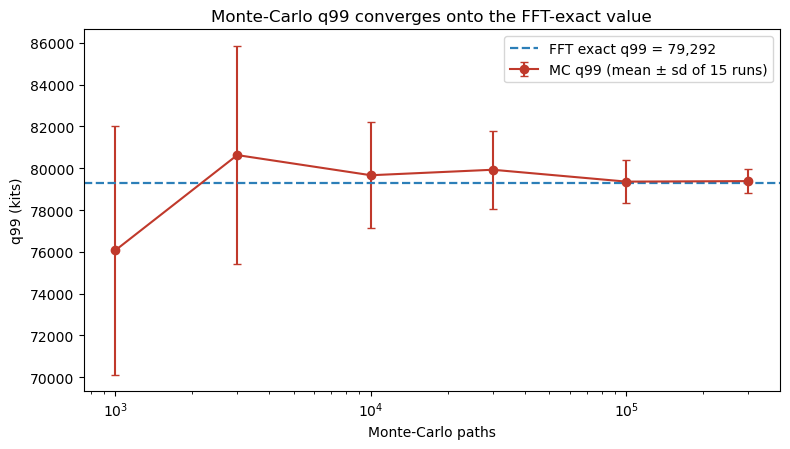

In [20]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 17 · §3b · Test (iv) tail convergence                          v1.1.0
# provides ▸ —
# requires ▸ aggregate_mc · Q99
# ══════════════════════════════════════════════════════════════════════════

# (iv) CONVERGENCE: Monte-Carlo q99 settles onto the FFT-exact Q99 as paths grow. The far
# quantile is where MC is noisiest, so this shows how many paths pin the overage-sizing tail.
sizes = [1_000, 3_000, 10_000, 30_000, 100_000, 300_000]
est = []
for n in sizes:
    reps = [np.quantile(aggregate_mc(np.random.default_rng(1000+j), n), 0.99) for j in range(15)]
    est.append((np.mean(reps), np.std(reps)))
est = np.array(est)

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.errorbar(sizes, est[:, 0], yerr=est[:, 1], marker="o", capsize=3, color="#c0392b",
            label="MC q99 (mean ± sd of 15 runs)")
ax.axhline(Q99, color="#2c7fb8", ls="--", lw=1.6, label=f"FFT exact q99 = {Q99:,}")
ax.set_xscale("log"); ax.set_xlabel("Monte-Carlo paths"); ax.set_ylabel("q99 (kits)")
ax.set_title("Monte-Carlo q99 converges onto the FFT-exact value")
ax.legend(loc="upper right"); plt.tight_layout(); plt.show()


### 3c. Tail control — exponential tilting *(stretch: implement yourself)*

Under-padding `M` aliases the far tail — exactly the overage quantile you care about. Padding fixes
it but costs memory. **Exponential tilting** (Grubel-Hermesmeier; Embrechts-Frei) controls aliasing
error in the tail at fixed `M`: tilt the severity by `e^{theta*x}`, run the same FFT, untilt the
result. Implementing it here is the single strongest depth signal in the piece — left as a TODO so
it's yours.

```
# TODO:
# 1. tilt:   g(x) = f(x) * exp(theta*x);   renormalise
# 2. run aggregate_fft on g
# 3. untilt: p_S(x) = agg_tilted(x) * exp(-theta*x) / G_N(exp(theta))-style constant
# 4. show the far-tail quantile is stable as theta varies, and beats the untilted FFT at small M
```

### 3d. Figures for the writeup

Four figures built on the validated model: the aliasing episode (why the tail needed a wider
lattice), the compound structure that underlies the whole model, the overage decision the
distribution feeds, and the FFT-versus-Monte-Carlo agreement with a zoom on the q99 tail.

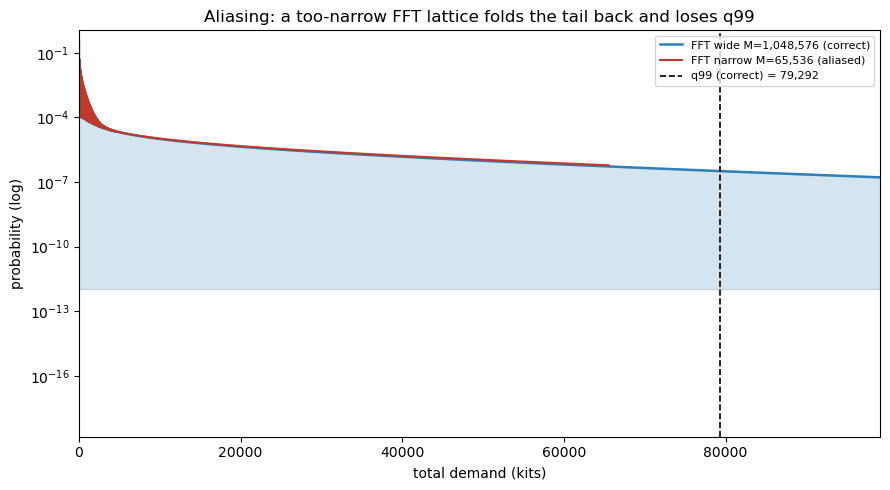

In [21]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 18 · §3d · Figure - aliasing in the tail                       v1.1.0
# provides ▸ —
# requires ▸ AGG · S_LATTICE · SEV · count_pgf · aggregate_fft · M · Q99
# ══════════════════════════════════════════════════════════════════════════

# Signature figure: a lattice DELIBERATELY narrower than q99 wraps the tail back, so it
# literally cannot represent the overage quantile - shown against the correct wide lattice.
M_narrow = 1 << int(np.floor(np.log2(Q99)))          # largest power of 2 below q99 -> aliases
AGG_narrow = aggregate_fft(SEV, count_pgf(), M_narrow)

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(S_LATTICE, AGG, 1e-12, color="#2c7fb8", alpha=.20)
ax.plot(S_LATTICE, AGG, lw=1.8, color="#2c7fb8", label=f"FFT wide M={M:,} (correct)")
ax.plot(np.arange(len(AGG_narrow)), AGG_narrow, lw=1.5, color="#c0392b",
        label=f"FFT narrow M={M_narrow:,} (aliased)")
ax.axvline(Q99, ls="--", color="k", lw=1.2, label=f"q99 (correct) = {Q99:,}")
ax.set_yscale("log"); ax.set_xlim(0, int(1.25*Q99)); ax.set_ylim(AGG[AGG>0].min()*0.5, AGG.max()*3)
ax.set_xlabel("total demand (kits)"); ax.set_ylabel("probability (log)")
ax.set_title("Aliasing: a too-narrow FFT lattice folds the tail back and loses q99")
ax.legend(loc="upper right", fontsize=8); plt.tight_layout(); plt.show()


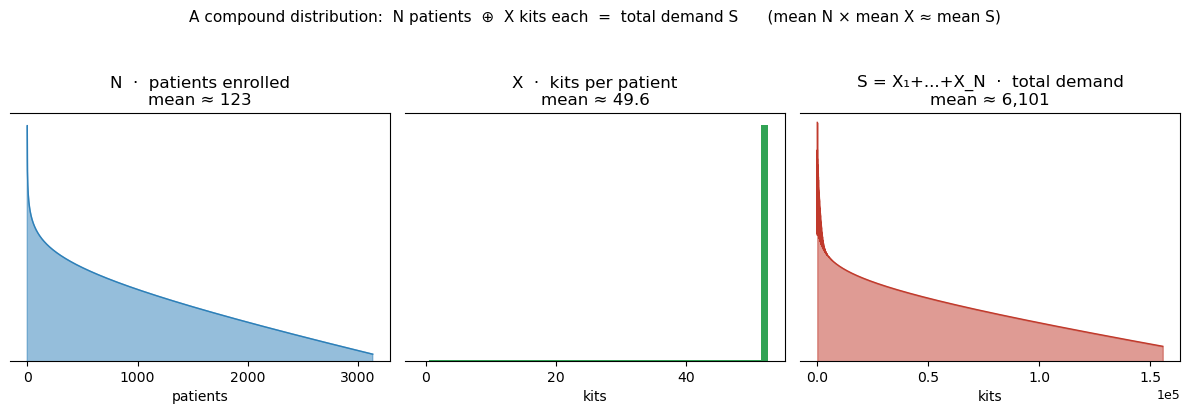

In [22]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 19 · §3d · Figure - compound structure (N, X, S)               v1.1.2
# provides ▸ —
# requires ▸ AGG · S_LATTICE · CDF · SEV · count_pgf · aggregate_fft
#            N_KIND · N_ARGS
# ══════════════════════════════════════════════════════════════════════════

# Teaches the compound structure: N patients (heavy-tailed count) each consume X kits, summed
# into total demand S. N reuses the FFT with a point-mass severity. Heavy tails -> log-y on N
# and S; X is a few discrete values (linear bars). Mean labels make N x X = S legible.
N_pmf = aggregate_fft(np.array([0.0, 1.0]), count_pgf(), 1 << 13)
EN = N_ARGS[0]*(1-N_ARGS[1])/N_ARGS[1] if N_KIND=="negbin" else N_ARGS[0]
EX = (np.arange(len(SEV))*SEV).sum(); ES = (S_LATTICE*AGG).sum()

fig, ax = plt.subplots(1, 3, figsize=(12, 3.9))
kN = int(np.searchsorted(np.cumsum(N_pmf), 0.999)) + 1
ax[0].fill_between(np.arange(kN), N_pmf[:kN], 1e-12, color="#2c7fb8", alpha=.5)
ax[0].plot(np.arange(kN), N_pmf[:kN], color="#2c7fb8", lw=1)
ax[0].set_yscale("log"); ax[0].set_ylim(1e-6, N_pmf.max()*2)
ax[0].set_title(f"N  ·  patients enrolled\nmean ≈ {EN:,.0f}"); ax[0].set_xlabel("patients")
ax[1].bar(np.arange(len(SEV)), SEV, color="#31a354", width=1.0)
ax[1].set_title(f"X  ·  kits per patient\nmean ≈ {EX:,.1f}"); ax[1].set_xlabel("kits")
kS = int(np.searchsorted(CDF, 0.999)) + 1
ax[2].fill_between(np.arange(kS), AGG[:kS], 1e-12, color="#c0392b", alpha=.5)
ax[2].plot(np.arange(kS), AGG[:kS], color="#c0392b", lw=1)
ax[2].set_yscale("log"); ax[2].set_ylim(1e-8, AGG.max()*2)
ax[2].set_title(f"S = X₁+...+X_N  ·  total demand\nmean ≈ {ES:,.0f}"); ax[2].set_xlabel("kits")
for a in ax:
    a.set_yticks([]); a.minorticks_off()
    a.tick_params(axis="y", which="both", left=False, labelleft=False)
    a.spines["left"].set_visible(False)
    a.locator_params(axis="x", nbins=5)                          # thin the x-ticks
    a.ticklabel_format(axis="x", style="sci", scilimits=(-4, 4)) # big kit counts as x10^n
    a.xaxis.get_offset_text().set_fontsize(9)
fig.suptitle("A compound distribution:  N patients  ⊕  X kits each  =  total demand S      "
             "(mean N × mean X ≈ mean S)", y=1.05, fontsize=11)
plt.tight_layout(); plt.show()


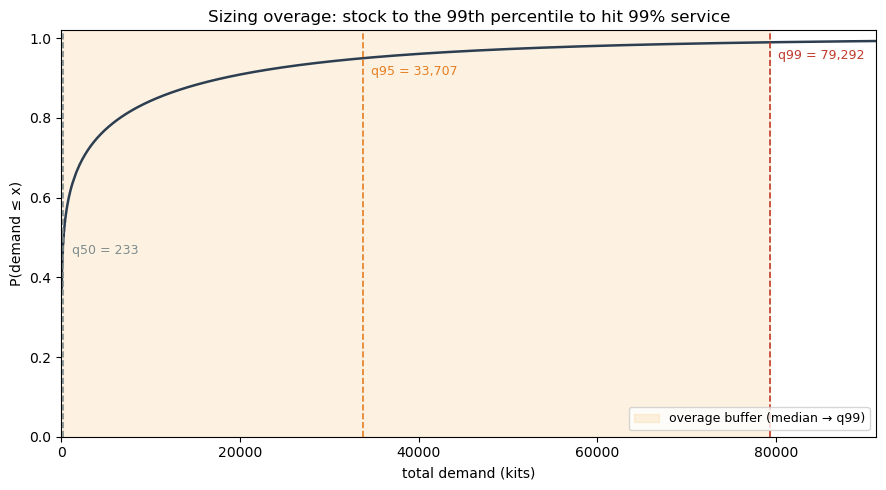

In [23]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 20 · §3d · Figure - the overage decision                       v1.1.0
# provides ▸ —
# requires ▸ S_LATTICE · CDF · Q50 · Q95 · Q99
# ══════════════════════════════════════════════════════════════════════════

# Connects the distribution to the supply decision: stock to q99 for 99% service. The band
# from the median to q99 is the overage buffer above typical demand. Reads CELL 12's CDF/Qs.
Q = {0.50: Q50, 0.95: Q95, 0.99: Q99}
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(S_LATTICE, CDF, lw=1.8, color="#2c3e50")
ax.axvspan(Q50, Q99, color="#f39c12", alpha=0.12, label="overage buffer (median → q99)")
for p, col in zip((0.50, 0.95, 0.99), ("#7f8c8d", "#e67e22", "#c0392b")):
    ax.axvline(Q[p], ls="--", color=col, lw=1.2)
    ax.annotate(f"q{int(p*100)} = {Q[p]:,}", (Q[p], p), xytext=(6, -12),
                textcoords="offset points", fontsize=9, color=col)
ax.set_xlim(0, int(Q99*1.15)); ax.set_ylim(0, 1.02)
ax.set_xlabel("total demand (kits)"); ax.set_ylabel("P(demand ≤ x)")
ax.set_title("Sizing overage: stock to the 99th percentile to hit 99% service")
ax.legend(loc="lower right", fontsize=9); plt.tight_layout(); plt.show()


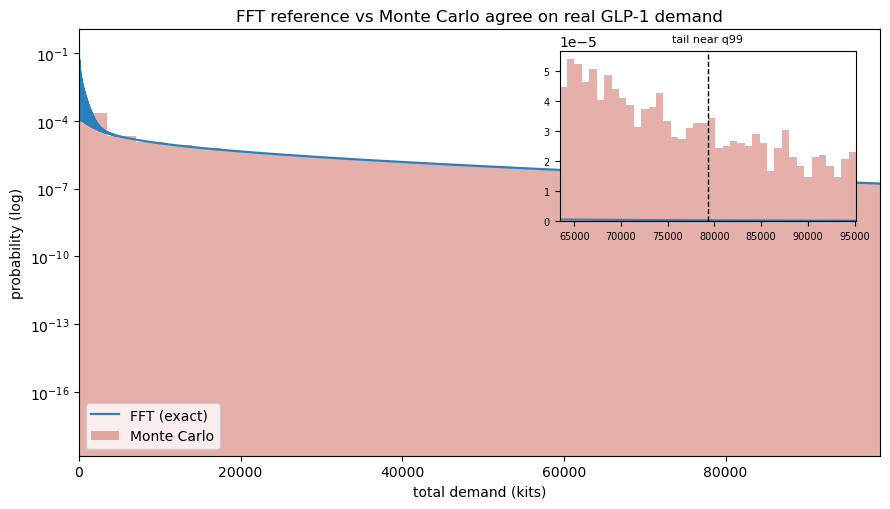

In [24]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 21 · §3d · Figure - FFT vs Monte Carlo (+ tail inset)          v1.1.0
# provides ▸ —
# requires ▸ AGG · S_LATTICE · S_MC · Q99
# ══════════════════════════════════════════════════════════════════════════

# The core claim in one figure: exact FFT and Monte Carlo agree on the real GLP-1 demand.
# Log-y so both show across the full range; a linear inset zooms the q99 tail that matters.
fig, ax = plt.subplots(figsize=(9, 5.2))
ax.plot(S_LATTICE, AGG, lw=1.6, color="#2c7fb8", label="FFT (exact)")
ax.hist(S_MC, bins=np.linspace(0, len(AGG), 300), density=True, alpha=.4, color="#c0392b", label="Monte Carlo")
ax.set_yscale("log"); ax.set_xlim(0, int(1.25*Q99)); ax.set_ylim(AGG[AGG>0].min()*0.5, AGG.max()*3)
ax.set_xlabel("total demand (kits)"); ax.set_ylabel("probability (log)")
ax.set_title("FFT reference vs Monte Carlo agree on real GLP-1 demand")
ax.legend(loc="lower left")
axin = ax.inset_axes([0.60, 0.55, 0.37, 0.40])
lo, hi = int(Q99*0.8), int(Q99*1.2); sel = (S_LATTICE >= lo) & (S_LATTICE <= hi)
axin.plot(S_LATTICE[sel], AGG[sel], lw=1.4, color="#2c7fb8")
mcsel = S_MC[(S_MC >= lo) & (S_MC <= hi)]
if len(mcsel): axin.hist(mcsel, bins=40, density=True, alpha=.4, color="#c0392b")
axin.axvline(Q99, ls="--", color="k", lw=1); axin.set_xlim(lo, hi)
axin.set_title("tail near q99", fontsize=8); axin.tick_params(labelsize=7)
plt.tight_layout(); plt.show()


## 4. Boundary of validity — where the exact reference stops

The FFT reference is exact **because**:
- per-patient consumption `X_i` is i.i.d. and independent of the count `N` — preserved by fixing the
  horizon, so consumption doesn't couple to how many enrol;
- severities live on an integer kit lattice, so there is no severity discretisation error — only
  aggregate wrap-around, which the aliasing check controls.

It stops being exact under real-world **dependence**, and that is where Monte Carlo earns its keep:
- shared site effects (enrolment correlated within a site);
- correlated dropout (a safety signal hitting a whole arm);
- cross-depot supply constraints (demand coupled through shared inventory).

**v2 roadmap:** introduce one dependence mechanism at a time; for each, the exact FFT no longer
applies, so MC becomes the primary — but you validate the *independent-core* limit of each extension
against this FFT reference. That is the honest use of an exact reference: not that reality is
independent, but that you can prove your simulator right where an exact answer exists, then trust it
where none does.

*Provenance note:* cite the NCT ids in `params['provenance']` in any writeup; a reader can open each
trial and check the numbers.